# 1. Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import json

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, f1_score
)

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
print("✅ Library siap")

d:\Tugas Besar ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Library siap


# 2. load dataset

In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nTarget Distribution:")
print(df['Churn'].value_counts())
print("\nTarget Ratio:")
print(df['Churn'].value_counts(normalize=True).round(3))
df.head()

Shape: (7043, 21)

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Target Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Target Ratio:
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 3. Feature dan Label

In [3]:
# Drop customerID (tidak prediktif)
df = df.drop(columns=['customerID'])

# TotalCharges ada yang kosong (string) → convert ke numerik
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Pisahkan feature dan label
X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

print("Features:", X.columns.tolist())
print("Total fitur:", X.shape[1])
print("Label values:", y.unique())
print("Label distribution:", y.value_counts().to_dict())

Features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
Total fitur: 19
Label values: [0 1]
Label distribution: {0: 5174, 1: 1869}


# 4. Split Dataset

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("\nDistribusi y_train:")
print(y_train.value_counts(normalize=True).round(3))
print("\nDistribusi y_val:")
print(y_val.value_counts(normalize=True).round(3))

X_train: (5634, 19)
X_val  : (1409, 19)

Distribusi y_train:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

Distribusi y_val:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


# 5. Preprocessing

In [5]:
# Handle missing values
# TotalCharges missing ~11 baris → isi median
X_train['TotalCharges'] = X_train['TotalCharges'].fillna(X_train['TotalCharges'].median())
X_val['TotalCharges']   = X_val['TotalCharges'].fillna(X_train['TotalCharges'].median())

# Missing flag untuk TotalCharges
X_train['TotalCharges_missing'] = X_train['TotalCharges'].isnull().astype(int)
X_val['TotalCharges_missing']   = X_val['TotalCharges'].isnull().astype(int)

# Label Encoding untuk kolom kategorikal
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
print("Kolom kategorikal:", cat_cols)

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_val[col]   = le.transform(X_val[col].astype(str))
    le_dict[col] = le

# Feature Engineering
# Pelanggan lama dengan contract bulanan → risiko churn
X_train['loyal_monthly'] = (
    (X_train['tenure'] > 24) &
    (X_train['Contract'] == 0)  # 0 = Month-to-month setelah encoding
).astype(int)
X_val['loyal_monthly'] = (
    (X_val['tenure'] > 24) &
    (X_val['Contract'] == 0)
).astype(int)

# Tagihan per bulan relatif terhadap tenure
X_train['charge_per_tenure'] = X_train['MonthlyCharges'] / (X_train['tenure'] + 1)
X_val['charge_per_tenure']   = X_val['MonthlyCharges'] / (X_val['tenure'] + 1)

# Banyak layanan tambahan → lebih terikat
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']
X_train['total_services'] = X_train[service_cols].sum(axis=1)
X_val['total_services']   = X_val[service_cols].sum(axis=1)

# Feature Scaling untuk kolom numerik
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
            'charge_per_tenure', 'total_services']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols]   = scaler.transform(X_val[num_cols])

print("\n✅ Preprocessing selesai")
print("Total fitur:", X_train.shape[1])
print("Kolom:", X_train.columns.tolist())

Kolom kategorikal: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

✅ Preprocessing selesai
Total fitur: 23
Kolom: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'TotalCharges_missing', 'loyal_monthly', 'charge_per_tenure', 'total_services']


# 6. Handling Imbalance dan Classifier

In [6]:
print("Sebelum SMOTE:", y_train.value_counts().to_dict())

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Sesudah SMOTE:", pd.Series(y_train_res).value_counts().to_dict())

classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
print("\n✅ Classifier siap:", classifier)

Sebelum SMOTE: {0: 4139, 1: 1495}
Sesudah SMOTE: {0: 4139, 1: 4139}

✅ Classifier siap: RandomForestClassifier(n_jobs=-1, random_state=42)


# 7. Training dan Hyperparameter

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 600),
        'max_depth'        : trial.suggest_int('max_depth', 8, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight'     : trial.suggest_categorical('class_weight', ['balanced', None]),
    }
    rf = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    score = cross_val_score(rf, X_train_res, y_train_res,
                            cv=cv, scoring='roc_auc', n_jobs=-1).mean()
    return score

study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n✅ Best ROC-AUC (CV): {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

best_rf = RandomForestClassifier(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train_res, y_train_res)
print("\n✅ Model selesai ditraining")

Best trial: 33. Best value: 0.917601: 100%|██████████| 50/50 [01:16<00:00,  1.54s/it]



✅ Best ROC-AUC (CV): 0.9176
Best params: {'n_estimators': 427, 'max_depth': 17, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': 'balanced'}

✅ Model selesai ditraining


# 8. Akurasi dan Threshold

In [8]:
y_proba = best_rf.predict_proba(X_val)[:, 1]

# Threshold optimization
thresholds = np.arange(0.1, 0.9, 0.01)
best_thresh, best_f1 = 0.5, 0

for thresh in thresholds:
    y_pred_t = (y_proba >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred_t, average='macro')
    if f1 > best_f1:
        best_f1     = f1
        best_thresh = thresh

y_pred = (y_proba >= best_thresh).astype(int)

print("=== AKURASI MODEL ===")
print(f"Accuracy         : {accuracy_score(y_val, y_pred):.4f}")
print(f"ROC-AUC          : {roc_auc_score(y_val, y_proba):.4f}")
print(f"Macro F1         : {f1_score(y_val, y_pred, average='macro'):.4f}")
print(f"Threshold optimal: {best_thresh:.2f}")

=== AKURASI MODEL ===
Accuracy         : 0.7878
ROC-AUC          : 0.8265
Macro F1         : 0.7253
Threshold optimal: 0.59


# 9. Confusion Matrix

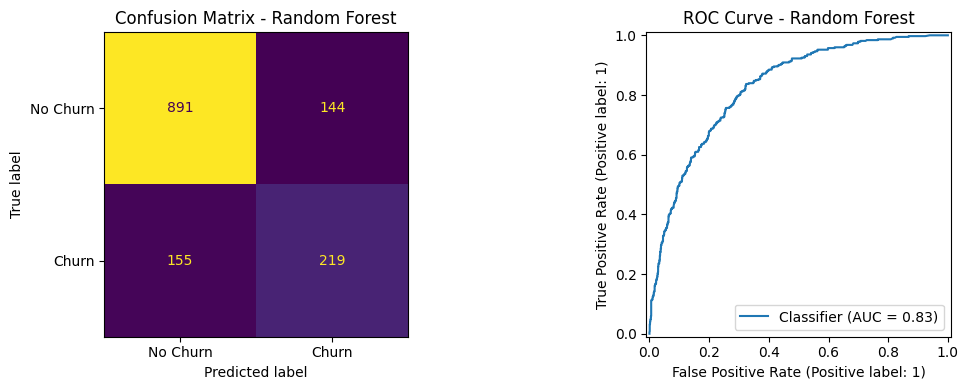

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred,
    display_labels=['No Churn', 'Churn'],
    ax=axes[0],
    colorbar=False
)
axes[0].set_title('Confusion Matrix - Random Forest')

RocCurveDisplay.from_predictions(y_val, y_proba, ax=axes[1])
axes[1].set_title('ROC Curve - Random Forest')

plt.tight_layout()
plt.show()

# 10. Detail Perbandingan

In [10]:
# Baseline
baseline_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
baseline_rf.fit(X_train_res, y_train_res)
y_proba_base = baseline_rf.predict_proba(X_val)[:, 1]
y_pred_base  = (y_proba_base >= 0.5).astype(int)

print("=== DETAIL HASIL PERBANDINGAN ===\n")
print("── Baseline Random Forest ──")
print(classification_report(y_val, y_pred_base,
      target_names=['No Churn', 'Churn']))
print(f"ROC-AUC  : {roc_auc_score(y_val, y_proba_base):.4f}")
print(f"Macro F1 : {f1_score(y_val, y_pred_base, average='macro'):.4f}")

print("\n── Tuned Random Forest ──")
print(classification_report(y_val, y_pred,
      target_names=['No Churn', 'Churn']))
print(f"ROC-AUC  : {roc_auc_score(y_val, y_proba):.4f}")
print(f"Macro F1 : {f1_score(y_val, y_pred, average='macro'):.4f}")

print("\n── Ringkasan ──")
cm_base = confusion_matrix(y_val, y_pred_base)
cm_tune = confusion_matrix(y_val, y_pred)

summary = pd.DataFrame({
    'Metrik'  : ['Accuracy', 'ROC-AUC', 'Macro F1',
                 'F1 Churn', 'Recall Churn', 'Threshold'],
    'Baseline': [
        round(accuracy_score(y_val, y_pred_base), 4),
        round(roc_auc_score(y_val, y_proba_base), 4),
        round(f1_score(y_val, y_pred_base, average='macro'), 4),
        round(f1_score(y_val, y_pred_base, average=None)[1], 4),
        round(cm_base[1][1] / cm_base[1].sum(), 4),
        0.50
    ],
    'Tuned'   : [
        round(accuracy_score(y_val, y_pred), 4),
        round(roc_auc_score(y_val, y_proba), 4),
        round(f1_score(y_val, y_pred, average='macro'), 4),
        round(f1_score(y_val, y_pred, average=None)[1], 4),
        round(cm_tune[1][1] / cm_tune[1].sum(), 4),
        round(best_thresh, 2)
    ]
})
print(summary.to_string(index=False))

=== DETAIL HASIL PERBANDINGAN ===

── Baseline Random Forest ──
              precision    recall  f1-score   support

    No Churn       0.86      0.81      0.84      1035
       Churn       0.55      0.65      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.71      1409
weighted avg       0.78      0.77      0.77      1409

ROC-AUC  : 0.8201
Macro F1 : 0.7150

── Tuned Random Forest ──
              precision    recall  f1-score   support

    No Churn       0.85      0.86      0.86      1035
       Churn       0.60      0.59      0.59       374

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.73      1409
weighted avg       0.79      0.79      0.79      1409

ROC-AUC  : 0.8265
Macro F1 : 0.7253

── Ringkasan ──
      Metrik  Baseline  Tuned
    Accuracy    0.7658 0.7878
     ROC-AUC    0.8201 0.8265
    Macro F1    0.7150 0.7253
    F1 Churn    0.5946 0.5943
Recall Churn    

# 11.  Coba V2

In [11]:
# Coba conservative params untuk naikkan Recall Churn
best_rf_v2 = RandomForestClassifier(
    n_estimators=427,
    max_depth=12,           # turunkan dari 17
    min_samples_split=2,
    min_samples_leaf=2,     # naikkan dari 1
    max_features='log2',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
best_rf_v2.fit(X_train_res, y_train_res)

y_proba_v2 = best_rf_v2.predict_proba(X_val)[:, 1]

# Re-optimize threshold
best_thresh_v2, best_f1_v2 = 0.5, 0
for thresh in np.arange(0.1, 0.9, 0.01):
    y_pred_t = (y_proba_v2 >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred_t, average='macro')
    if f1 > best_f1_v2:
        best_f1_v2     = f1
        best_thresh_v2 = thresh

y_pred_v2 = (y_proba_v2 >= best_thresh_v2).astype(int)
cm_v2     = confusion_matrix(y_val, y_pred_v2)

print("=== PERBANDINGAN ===")
print(f"{'Metrik':<20} {'Tuned v1':>10} {'Tuned v2':>10}")
print(f"{'ROC-AUC':<20} {roc_auc_score(y_val, y_proba):>10.4f} {roc_auc_score(y_val, y_proba_v2):>10.4f}")
print(f"{'Macro F1':<20} {best_f1:>10.4f} {best_f1_v2:>10.4f}")
print(f"{'Recall Churn':<20} {cm_tune[1][1]/cm_tune[1].sum():>10.4f} {cm_v2[1][1]/cm_v2[1].sum():>10.4f}")
print(f"{'Threshold':<20} {best_thresh:>10.2f} {best_thresh_v2:>10.2f}")

=== PERBANDINGAN ===
Metrik                 Tuned v1   Tuned v2
ROC-AUC                  0.8265     0.8366
Macro F1                 0.7253     0.7336
Recall Churn             0.5856     0.6738
Threshold                  0.59       0.56


# 12. Feature Engineering final


In [12]:
def add_telco_features(df):
    df = df.copy()
    
    # Pelanggan baru dengan tagihan tinggi → risiko churn
    df['new_high_charge'] = (
        (df['tenure'] < 0) &  # sudah di-scale, negatif = tenure pendek
        (df['MonthlyCharges'] > 0)
    ).astype(int)
    
    # Tidak ada proteksi/backup → mudah pindah
    df['no_protection'] = (
        (df['OnlineSecurity'] == 0) &
        (df['OnlineBackup'] == 0) &
        (df['DeviceProtection'] == 0)
    ).astype(int)
    
    # Tidak ada support → tidak terikat
    df['no_support'] = (
        (df['TechSupport'] == 0) &
        (df['StreamingTV'] == 0) &
        (df['StreamingMovies'] == 0)
    ).astype(int)
    
    # Pembayaran elektronik + contract bulanan → sangat mudah cancel
    df['easy_cancel'] = (
        (df['Contract'] == 0) &
        (df['PaperlessBilling'] == 1)
    ).astype(int)
    
    # Ratio tagihan total vs bulanan (konsistensi pembayaran)
    df['charge_ratio'] = df['TotalCharges'] / (df['MonthlyCharges'] + 0.001)
    
    return df

X_train_fe = add_telco_features(X_train_res)
X_val_fe   = add_telco_features(X_val)

print("Total fitur:", X_train_fe.shape[1])
print("Fitur baru:", [c for c in X_train_fe.columns if c not in X_train_res.columns])

# Train dengan params v2
best_rf_fe = RandomForestClassifier(
    n_estimators=427,
    max_depth=12,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='log2',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
best_rf_fe.fit(X_train_fe, y_train_res)

y_proba_fe = best_rf_fe.predict_proba(X_val_fe)[:, 1]

# Threshold optimization
best_thresh_fe, best_f1_fe = 0.5, 0
for thresh in np.arange(0.1, 0.9, 0.01):
    y_pred_t = (y_proba_fe >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred_t, average='macro')
    if f1 > best_f1_fe:
        best_f1_fe     = f1
        best_thresh_fe = thresh

y_pred_fe = (y_proba_fe >= best_thresh_fe).astype(int)
cm_fe     = confusion_matrix(y_val, y_pred_fe)

print("\n=== PERBANDINGAN ===")
print(f"{'Metrik':<20} {'v2 (best)':>10} {'FE':>10}")
print(f"{'ROC-AUC':<20} {'0.8366':>10} {roc_auc_score(y_val, y_proba_fe):>10.4f}")
print(f"{'Macro F1':<20} {'0.7336':>10} {f1_score(y_val, y_pred_fe, average='macro'):>10.4f}")
print(f"{'Recall Churn':<20} {'0.6738':>10} {cm_fe[1][1]/cm_fe[1].sum():>10.4f}")
print(f"{'Threshold':<20} {'0.56':>10} {best_thresh_fe:>10.2f}")

Total fitur: 28
Fitur baru: ['new_high_charge', 'no_protection', 'no_support', 'easy_cancel', 'charge_ratio']

=== PERBANDINGAN ===
Metrik                v2 (best)         FE
ROC-AUC                  0.8366     0.8357
Macro F1                 0.7336     0.7350
Recall Churn             0.6738     0.6791
Threshold                  0.56       0.56


# 13. Simpan Model

In [13]:
os.makedirs('../models', exist_ok=True)

joblib.dump(best_rf_fe, '../models/random_forest_model.pkl')
joblib.dump(scaler, '../models/rf_scaler.pkl')
joblib.dump(le_dict, '../models/rf_label_encoders.pkl')

feature_names = X_train_fe.columns.tolist()
joblib.dump(feature_names, '../models/selected_features.pkl')

with open('../models/best_params_rf.json', 'w') as f:
    json.dump({
        'n_estimators'     : 427,
        'max_depth'        : 12,
        'min_samples_split': 2,
        'min_samples_leaf' : 2,
        'max_features'     : 'log2',
        'class_weight'     : 'balanced'
    }, f, indent=2)

joblib.dump({
    'n_features'   : X_train_fe.shape[1],
    'feature_names': feature_names,
    'model_version': 'RF+FE+Tuned+Telco',
    'auc'          : round(roc_auc_score(y_val, y_proba_fe), 4),
    'macro_f1'     : round(best_f1_fe, 4),
    'threshold'    : round(best_thresh_fe, 2)
}, '../models/model_metadata.pkl')

print("✅ Model final (FE) tersimpan!")
print(f"AUC       : {roc_auc_score(y_val, y_proba_fe):.4f}")
print(f"Macro F1  : {best_f1_fe:.4f}")
print(f"Threshold : {best_thresh_fe:.2f}")
print("Files:", os.listdir('../models'))

✅ Model final (FE) tersimpan!
AUC       : 0.8357
Macro F1  : 0.7350
Threshold : 0.56
Files: ['best_params_knn.json', 'best_params_rf.json', 'knn_metadata.pkl', 'knn_model.pkl', 'knn_preprocessor.pkl', 'knn_selected_features.pkl', 'model_metadata.pkl', 'preprocessor_knn.pkl', 'random_forest_model.pkl', 'rf_label_encoders.pkl', 'rf_scaler.pkl', 'selected_features.pkl']


# 14. Sanity Check


In [14]:
sample       = X_val_fe.iloc[:5]
proba_sample = best_rf_fe.predict_proba(sample)[:, 1]
pred_sample  = (proba_sample >= best_thresh_fe).astype(int)

result = pd.DataFrame({
    'Actual'     : y_val.iloc[:5].values,
    'Predicted'  : pred_sample,
    'Prob(Churn)': proba_sample.round(3)
})
print("=== SANITY CHECK ===")
print(result)

=== SANITY CHECK ===
   Actual  Predicted  Prob(Churn)
0       0          0        0.003
1       0          1        0.892
2       0          0        0.136
3       0          0        0.420
4       0          0        0.049
